In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


In [33]:
df = pd.read_excel('/content/heart_disease.xlsx')

In [37]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,Male,asymptomatic,125,0,False,normal,120,False,1.5,upsloping,reversable defect,4
904,62,Male,asymptomatic,166,170,False,st-t abnormality,120,True,3.0,flat,normal,4
905,56,Male,non-anginal,170,0,False,lv hypertrophy,123,True,2.5,downsloping,fixed defect,4
906,56,Male,non-anginal,144,208,True,st-t abnormality,105,TURE,NaN,downsloping,fixed defect,4


In [38]:
df.shape

(908, 13)

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [40]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,62


In [41]:
df.duplicated().sum()

np.int64(1)

In [42]:
median = df['oldpeak'].median()
df['oldpeak'] = df['oldpeak'].fillna(median)

In [43]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,0


array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'trestbps'}>],
       [<Axes: title={'center': 'chol'}>,
        <Axes: title={'center': 'thalch'}>],
       [<Axes: title={'center': 'oldpeak'}>,
        <Axes: title={'center': 'num'}>]], dtype=object)

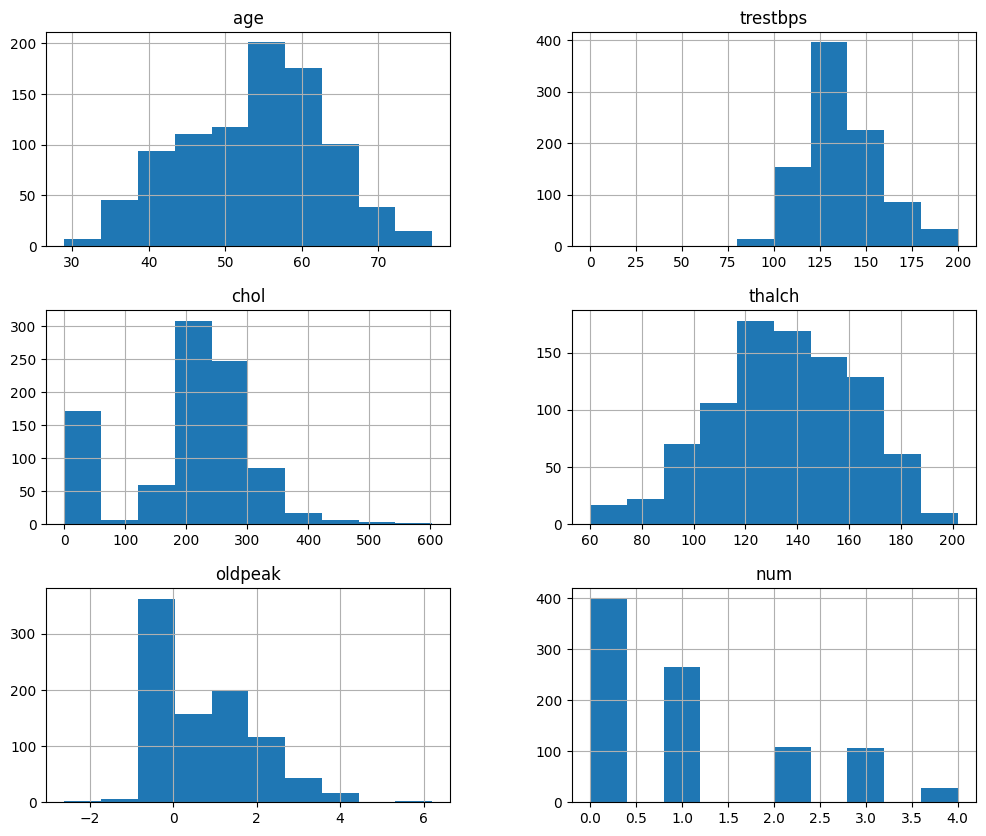

In [44]:
df.hist(figsize=(12,10))

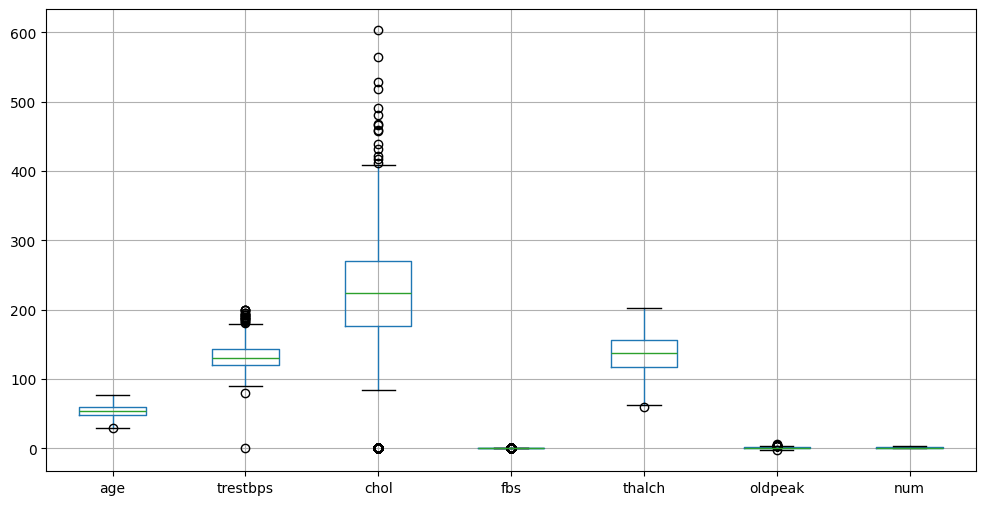

In [45]:
df.boxplot(figsize=(12,6))
plt.show()

In [46]:
for i in df.select_dtypes(include=['int','float']).columns:
  q1 = df[i].quantile(0.25)
  q3 = df[i].quantile(0.75)
  iqr = q3-q1
  lower = q1 - 1.5*iqr
  upper = q3 + 1.5*iqr

  df[i] = df[i].clip(lower,upper)

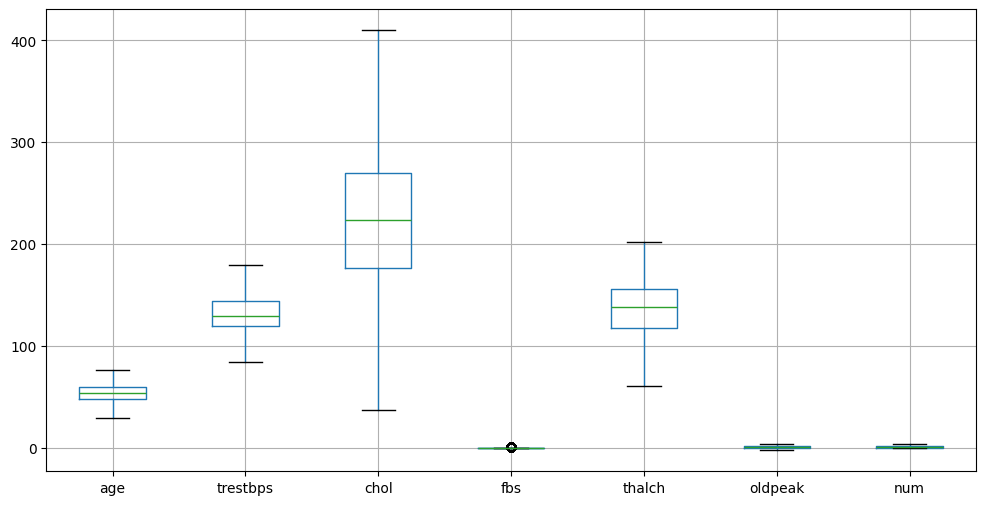

In [47]:
df.boxplot(figsize=(12,6))
plt.show()

In [48]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63.0,Male,typical angina,145,233.000,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41.0,Male,atypical angina,135,203.000,False,normal,132,False,0.0,flat,fixed defect,0
2,57.0,Male,asymptomatic,140,192.000,False,normal,148,False,0.4,flat,fixed defect,0
3,52.0,Male,typical angina,118,186.000,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57.0,Male,asymptomatic,110,201.000,False,normal,126,True,1.5,flat,fixed defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53.0,Male,asymptomatic,125,36.875,False,normal,120,False,1.5,upsloping,reversable defect,4
904,62.0,Male,asymptomatic,166,170.000,False,st-t abnormality,120,True,3.0,flat,normal,4
905,56.0,Male,non-anginal,170,36.875,False,lv hypertrophy,123,True,2.5,downsloping,fixed defect,4
906,56.0,Male,non-anginal,144,208.000,True,st-t abnormality,105,TURE,0.5,downsloping,fixed defect,4


In [49]:
df['exang'] = df['exang'].astype(str)

In [50]:
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
lb = LabelEncoder()
df['sex'] = lb.fit_transform(df['sex'])
df['fbs'] = lb.fit_transform(df['fbs'])
# df['exang'] = lb.fit_transform(df['exang'])
# df['thal'] = lb.fit_transform(df['thal'])
# df['slope'] = lb.fit_transform(df['slope'])
# df['cp'] = lb.fit_transform(df['cp'])
# df['restecg'] = lb.fit_transform(df['restecg'])

In [51]:
# df = pd.get_dummies(df,columns=['thal'],dtype='int')
# df = pd.get_dummies(df,columns=['slope'],dtype='int')
# df = pd.get_dummies(df,columns=['restecg'],dtype='int')
# df = pd.get_dummies(df,columns=['cp'],dtype='int')
# encoding
df = pd.get_dummies(df, drop_first=True).astype(int)


In [52]:
df

,age,sex,trestbps,chol,fbs,thalch,oldpeak,num,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,exang_False,exang_TURE,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,1,145,233,1,150,2,0,0,0,1,0,0,1,0,0,0,0,0,0
1,41,1,135,203,0,132,0,0,1,0,0,1,0,1,0,0,1,0,0,0
2,57,1,140,192,0,148,0,0,0,0,0,1,0,1,0,0,1,0,0,0
3,52,1,118,186,0,190,0,0,0,0,1,0,0,1,0,0,1,0,0,0
4,57,1,110,201,0,126,1,0,0,0,0,1,0,0,0,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,1,125,36,0,120,1,4,0,0,0,1,0,1,0,0,0,1,0,1
904,62,1,166,170,0,120,3,4,0,0,0,0,1,0,0,1,1,0,1,0
905,56,1,170,36,0,123,2,4,0,1,0,0,0,0,0,1,0,0,0,0
906,56,1,144,208,1,105,0,4,0,1,0,0,1,0,1,0,0,0,0,0


In [53]:
from sklearn.preprocessing import MinMaxScaler
ms = MinMaxScaler()
df['trestbps'] = ms.fit_transform(df[['trestbps']])
df['thalch'] = ms.fit_transform(df[['thalch']])
df['oldpeak'] = ms.fit_transform(df[['oldpeak']])

In [54]:
x = df.drop(columns = 'num')
y = df['num']

In [55]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state=55)
x_train.shape,x_test.shape,y_train.shape

((726, 19), (182, 19), (726,))

In [56]:
# from sklearn.preprocessing import StandardScaler
# ss = StandardScaler()
# x_train_s = ss.fit_transform(x_train)
# x_test_s = ss.transform(x_test)


In [57]:
from sklearn.tree import DecisionTreeClassifier
dc = DecisionTreeClassifier()
dc.fit(x_train,y_train)
pred = dc.predict(x_test)

In [58]:
from sklearn.metrics import accuracy_score,classification_report, roc_auc_score
print(accuracy_score(y_test,pred))
print(classification_report(y_test,pred))


0.45604395604395603
              precision    recall  f1-score   support

           0       0.67      0.63      0.65        84
           1       0.38      0.42      0.40        57
           2       0.00      0.00      0.00        13
           3       0.33      0.27      0.30        22
           4       0.00      0.00      0.00         6

    accuracy                           0.46       182
   macro avg       0.28      0.26      0.27       182
weighted avg       0.47      0.46      0.46       182



In [59]:
from sklearn.metrics import roc_auc_score
y_prob = dc.predict_proba(x_test)
roc_auc_score(y_test, y_prob, multi_class='ovr')

np.float64(0.5543425355924199)

In [60]:
from sklearn.model_selection import GridSearchCV

grid = {
    'max_depth' : [2,3,4,5,6,7,8,9,None],
    'min_samples_split' : [2,3,4,5,6,7,8,9,10],
    'min_samples_leaf': [1,2,3,4],
    'criterion' : ['gini','entropy']
}

In [61]:
grid_search = GridSearchCV(
    estimator=dc,
    param_grid = grid,
    cv=5,
    scoring = 'accuracy',
    n_jobs = -1
)

grid_search.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 3, 4, 5, 6, 7, 8, 9, None],
                         'min_samples_leaf': [1, 2, 3, 4],
                         'min_samples_split': [2, 3, 4, 5, 6, 7, 8, 9, 10]},
             scoring='accuracy')

In [62]:
print('best parameters :', grid_search.best_params_)
print('best parameters :', grid_search.best_score_)

best parameters : {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 4, 'min_samples_split': 2}
best parameters : 0.5454794520547945


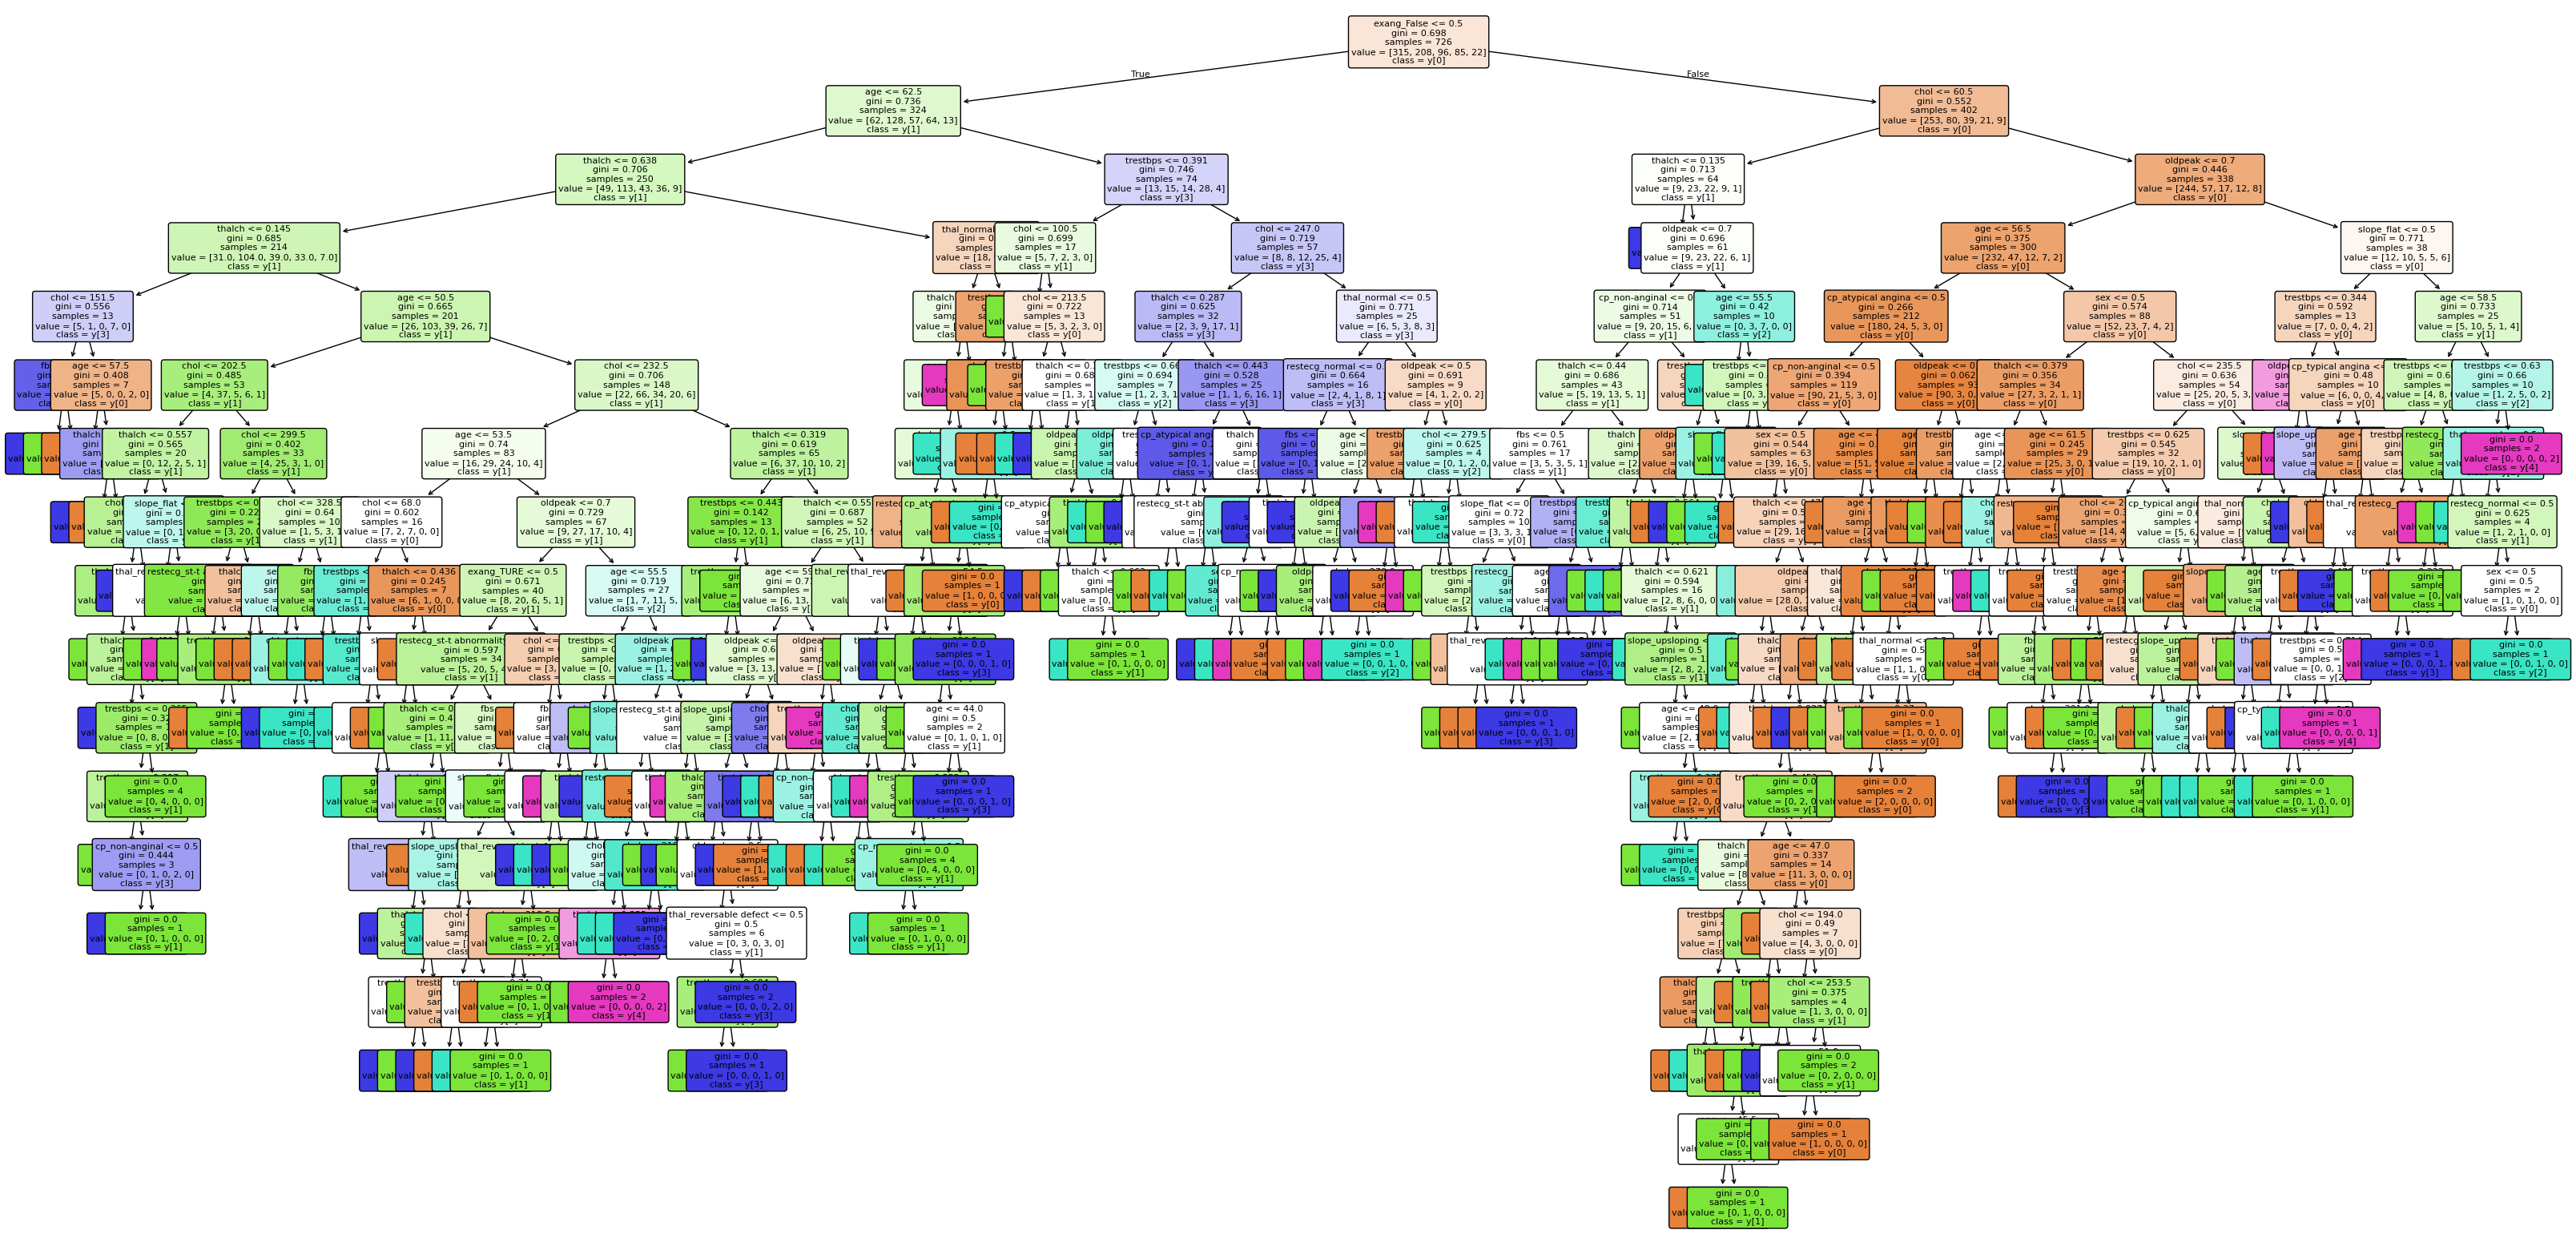

In [63]:
from sklearn.tree import plot_tree
plt.figure(figsize=(40, 20))
plot_tree(

    dc,

    filled=True,

    rounded=True,

    fontsize=8,

    feature_names=x.columns,

    class_names=True
)

plt.show()

Interview Questions:
1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?



Decision tree hyperparameters control the tree's complexity. Increasing complexity (deeper trees) can improve training accuracy but often causes overfitting, while restricting the tree improves generalization on unseen data.

2. What is the difference between the Label encoding and One-hot encoding?

Label Encoding converts categories into integers and is best for ordinal data. One-Hot Encoding creates separate binary columns for each category and is preferred for nominal data because it avoids introducing false relationships between categories.